In [1]:
from pathlib import Path
import json
import seaborn as sns

# Samegame 2x3c3s2

In [2]:
mlp_single = json.load(Path("results/exp_mlp_samegame2x3c3s2_averaged/agent_eval.json").open())
mlp_dyad_a = json.load(Path("results/exp_dyad_mlp_samegame2x3c3s2_averaged/agent_a_eval.json").open())
mlp_dyad_b = json.load(Path("results/exp_dyad_mlp_samegame2x3c3s2_averaged/agent_b_eval.json").open())
mlp_dyad_sharing = json.load(Path("results/exp_dyad_mlp_samegame2x3c3s2_averaged/sharing_stats.json").open())

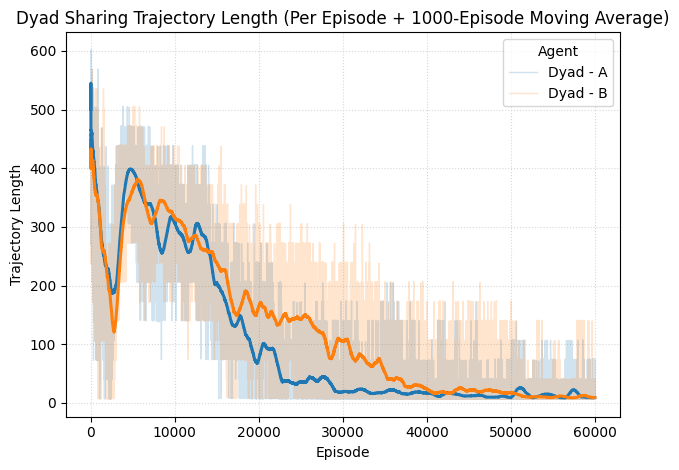

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_dyad_sharing_trajectory(mlp_dyad_sharing, window=1000):
    sharing_df = pd.DataFrame(mlp_dyad_sharing)
    sharing_df = sharing_df.sort_values("episode").copy()

    sharing_df["traj_a_len"] = sharing_df["traj_a_len"].astype(float)
    sharing_df["traj_b_len"] = sharing_df["traj_b_len"].astype(float)

    long_df = pd.concat(
        [
            sharing_df[["episode", "traj_a_len"]].rename(columns={"traj_a_len": "trajectory_length"}).assign(Agent="Dyad - A"),
            sharing_df[["episode", "traj_b_len"]].rename(columns={"traj_b_len": "trajectory_length"}).assign(Agent="Dyad - B"),
        ],
        ignore_index=True,
    ).sort_values(["Agent", "episode"])

    long_df["trajectory_length_ma1000"] = long_df.groupby("Agent")["trajectory_length"].transform(
        lambda s: s.rolling(window=window, min_periods=1).mean()
    )

    ax = sns.lineplot(
        data=long_df,
        x="episode",
        y="trajectory_length",
        hue="Agent",
        alpha=0.2,
        linewidth=1.0,
        legend=True,
    )

    sns.lineplot(
        data=long_df,
        x="episode",
        y="trajectory_length_ma1000",
        hue="Agent",
        linewidth=2.2,
        ax=ax,
        legend=False,
    )

    ax.set_xlabel("Episode")
    ax.set_ylabel("Trajectory Length")
    ax.set_title("Dyad Sharing Trajectory Length (Per Episode + 1000-Episode Moving Average)")
    ax.grid(True, color="lightgrey", linestyle=":", linewidth=0.8, alpha=0.9)
    plt.tight_layout()

plot_dyad_sharing_trajectory(mlp_dyad_sharing)

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_agent_performance(series_data, title_plot):
    """
    Plot agent performance with SEM bands for any number of series.

    Args:
        series_data: list of (eval_data, legend_label) tuples where eval_data is
            a list of dicts containing episode/avg_length and optional sem_length.
        title_plot: plot title.
    """
    if not series_data:
        raise ValueError("series_data must contain at least one (data, label) pair")

    frames = []
    for eval_data, legend_label in series_data:
        df = pd.DataFrame(
            [(d['episode'], d['avg_length'], d.get('sem_length', 0.0)) for d in eval_data],
            columns=['episode', 'avg_length', 'sem_length']
        )
        df['Agent'] = legend_label
        frames.append(df)

    combined_df = pd.concat(frames, ignore_index=True)

    ax = sns.lineplot(
        data=combined_df,
        x='episode',
        y='avg_length',
        hue='Agent',
        errorbar=None
    )

    # SEM band around each mean line
    for line, (agent, group) in zip(ax.lines, combined_df.groupby('Agent', sort=False)):
        group = group.sort_values('episode')
        x = group['episode'].to_numpy()
        y = group['avg_length'].to_numpy()
        sem = group['sem_length'].to_numpy()
        lower = np.clip(y - sem, 0.0, None)
        upper = y + sem
        ax.fill_between(x, lower, upper, color=line.get_color(), alpha=0.18)

    ax.set_ylabel('Average Solution Length')
    ax.set_xlabel('Learning Episode')
    ax.set_title(title_plot)
    ax.grid(True, color='lightgrey', linestyle=':', linewidth=0.8, alpha=0.9)
    plt.tight_layout()

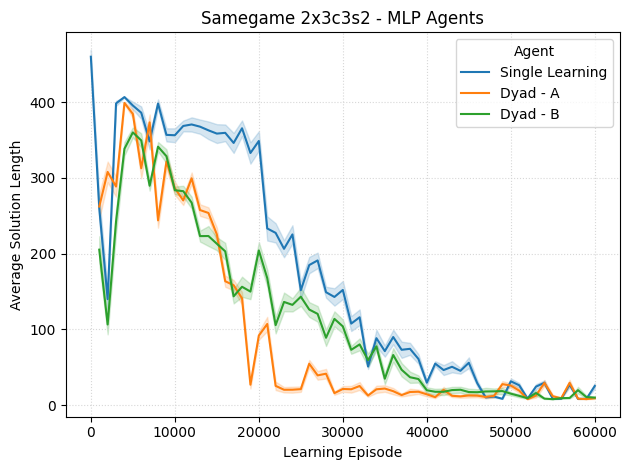

In [5]:
plot_agent_performance([(mlp_single, "Single Learning"), (mlp_dyad_a, "Dyad - A"), (mlp_dyad_b, "Dyad - B")], "Samegame 2x3c3s2 - MLP Agents")

Now plot performance of the agents on the 2x3c3s2 game, where the dyad agents are accepting **all** Transitions.

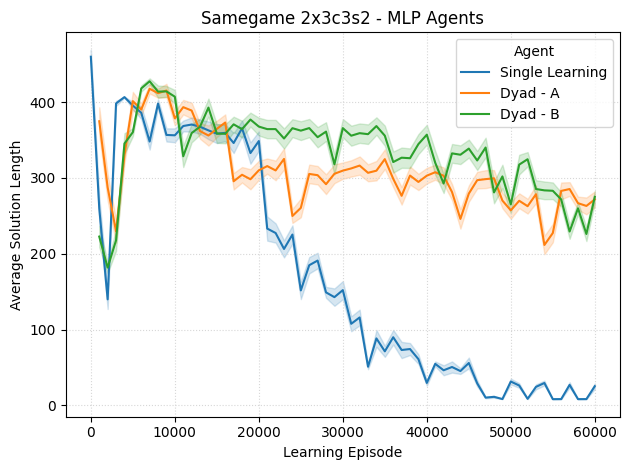

In [6]:
mlp_single = json.load(Path("results/exp_mlp_samegame2x3c3s2_averaged/agent_eval.json").open())
mlp_dyad_a = json.load(Path("results/exp_dyad_mlp_accept_all_samegame2x3c3s2_averaged/agent_a_eval.json").open())
mlp_dyad_b = json.load(Path("results/exp_dyad_mlp_accept_all_samegame2x3c3s2_averaged/agent_b_eval.json").open())

plot_agent_performance([(mlp_single, "Single Learning"), (mlp_dyad_a, "Dyad - A"), (mlp_dyad_b, "Dyad - B")], "Samegame 2x3c3s2 - MLP Agents")

## Additional experiments

In [7]:
mlp_single_large_eps = json.load(Path("results_new/exp_mlp_samegame2x3c3s2_large_eps/agent_eval.json").open())
mlp_single_all_random = json.load(Path("results/exp_mlp_samegame_2x3c3s2_all_random_averaged/agent_eval.json").open())

cnn_mlp_dyad_a = json.load(Path("results_new/exp_dyad_cnn_mlp_samegame2x3c3s2_large_eps1/agent_a_eval.json").open())
cnn_mlp_dyad_b = json.load(Path("results_new/exp_dyad_cnn_mlp_samegame2x3c3s2_large_eps1/agent_b_eval.json").open())
cnn_mlp_dyad_sharing = json.load(Path("results_new/exp_dyad_cnn_mlp_samegame2x3c3s2_large_eps1/sharing_stats.json").open())

pooling_cnn_mlp_dyad_a = json.load(Path("results_new/dyad_cnn_mlp_with_pooling_large_image_normal_eps/agent_a_eval.json").open())
pooling_cnn_mlp_dyad_b = json.load(Path("results_new/dyad_cnn_mlp_with_pooling_large_image_normal_eps/agent_b_eval.json").open())
pooling_cnn_mlp_dyad_sharing = json.load(Path("results_new/dyad_cnn_mlp_with_pooling_large_image_normal_eps/sharing_stats.json").open())


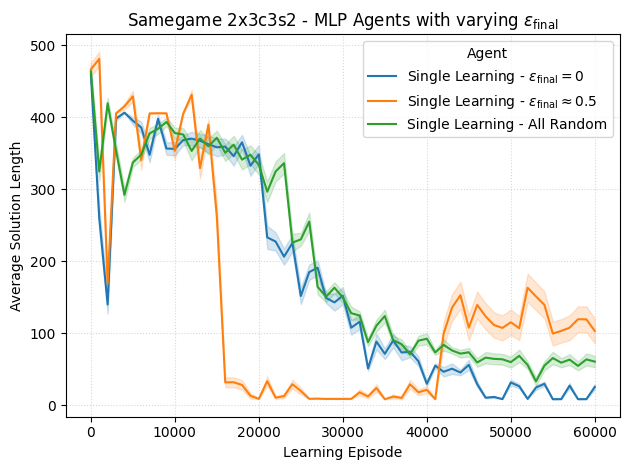

In [8]:
plot_agent_performance(
    [
        (mlp_single, r'Single Learning - $\epsilon_\mathrm{final}=0$'),
        (mlp_single_large_eps, r'Single Learning - $\epsilon_\mathrm{final} \approx 0.5$'),
        (mlp_single_all_random, r'Single Learning - All Random'),
    ],
    r'Samegame 2x3c3s2 - MLP Agents with varying $\epsilon_\mathrm{final}$'
 )

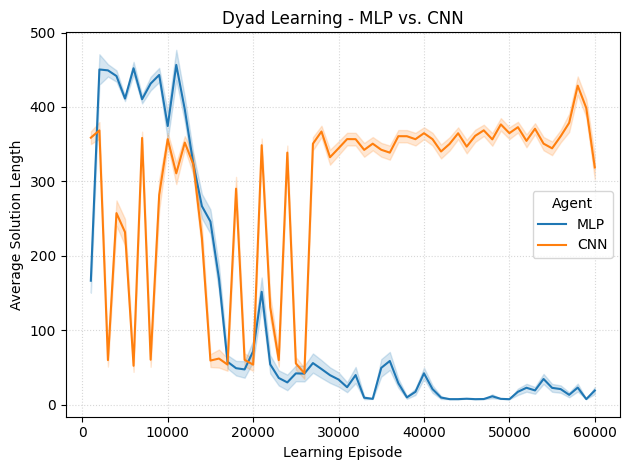

In [9]:
plot_agent_performance(
    [
        (cnn_mlp_dyad_a, 'MLP'),
        (cnn_mlp_dyad_b, 'CNN'),
    ],
    'Dyad Learning - MLP vs. CNN'
 )

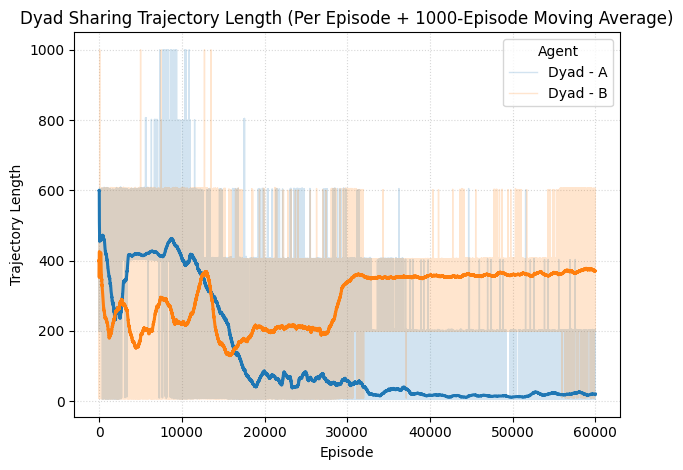

In [10]:
plot_dyad_sharing_trajectory(cnn_mlp_dyad_sharing)

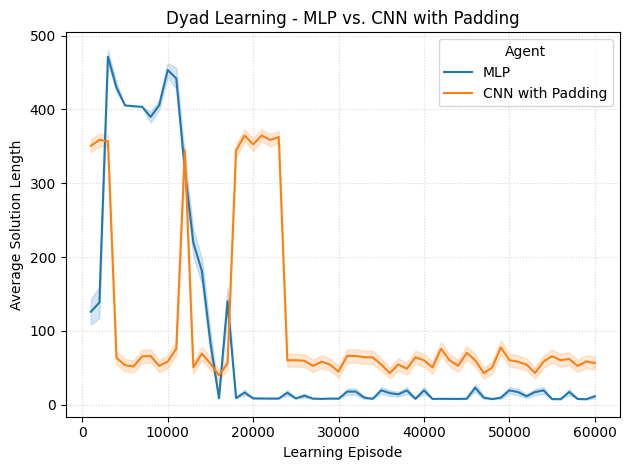

In [11]:
plot_agent_performance(
    [
        (pooling_cnn_mlp_dyad_a, 'MLP'),
        (pooling_cnn_mlp_dyad_b, 'CNN with Padding'),
    ],
    'Dyad Learning - MLP vs. CNN with Padding'
 )

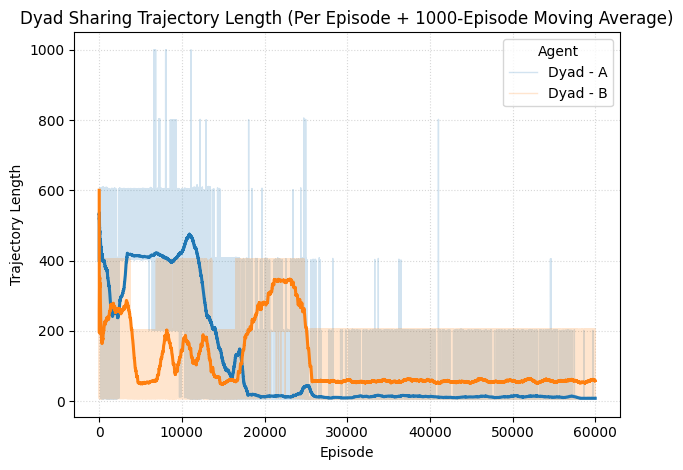

In [12]:
plot_dyad_sharing_trajectory(pooling_cnn_mlp_dyad_sharing)

In [27]:
def plot_dyad_sharing_trajectory(mlp_dyad_sharing, window=1000):
    sharing_df = pd.DataFrame(mlp_dyad_sharing)
    sharing_df = sharing_df.sort_values("episode").copy()

    sharing_df["traj_a_len"] = sharing_df["traj_a_len"].astype(float)
    sharing_df["traj_b_len"] = sharing_df["traj_b_len"].astype(float)

    long_df = pd.concat(
        [
            sharing_df[["episode", "traj_a_len"]].rename(columns={"traj_a_len": "trajectory_length"}).assign(Agent="MLP"),
            sharing_df[["episode", "traj_b_len"]].rename(columns={"traj_b_len": "trajectory_length"}).assign(Agent="CNN with Padding"),
        ],
        ignore_index=True,
    ).sort_values(["Agent", "episode"])

    long_df["trajectory_length_ma1000"] = long_df.groupby("Agent")["trajectory_length"].transform(
        lambda s: s.rolling(window=window, min_periods=1).mean()
    )

    ax = sns.lineplot(
        data=long_df,
        x="episode",
        y="trajectory_length",
        hue="Agent",
        hue_order=["MLP", "CNN with Padding"],
        alpha=0.2,
        linewidth=1.0,
        legend=True,
    )

    sns.lineplot(
        data=long_df,
        x="episode",
        y="trajectory_length_ma1000",
        hue="Agent",
        hue_order=["MLP", "CNN with Padding"],
        linewidth=2.2,
        ax=ax,
        legend=False,
    )

    ax.set_xlabel("Episode")
    ax.set_ylabel("Trajectory Length")
    ax.set_title("Dyad Sharing Trajectory Length (Per Episode + 1000-Episode Moving Average)")
    ax.grid(True, color="lightgrey", linestyle=":", linewidth=0.8, alpha=0.9)
    plt.tight_layout()

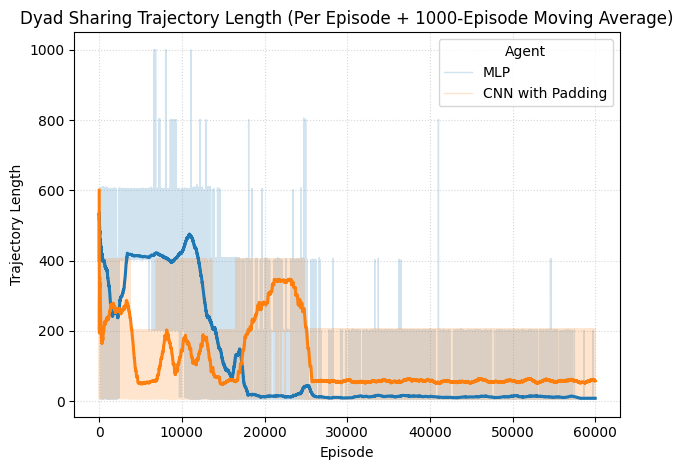

In [28]:

plot_dyad_sharing_trajectory(pooling_cnn_mlp_dyad_sharing)